In [1]:
# Module 2 - Titanic Analytics
# Task 1: Load, profile, and save offline fallback

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create analytics folder
os.makedirs("analytics", exist_ok=True)

# Load Titanic dataset ONCE
df = sns.load_dataset("titanic")

# Immediately save offline fallback
df.to_csv("analytics/titanic.csv", index=False)

print("Dataset loaded and offline fallback saved.")
print("\n--- df.info() ---")
df.info()

print("\n--- df.describe() ---")
display(df.describe(include="all"))

print("\n--- df.shape ---")
print(df.shape)

print("\n--- Missing values ---")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_pct
})

display(missing_report[missing_report["missing_count"] > 0])

Dataset loaded and offline fallback saved.

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- df.describe(

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- df.shape ---
(891, 15)

--- Missing values ---


,missing_count,missing_percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [5]:
# Task 2: Missing-value handling

print("Missing-value strategy:")
print("- age: 19.87% missing -> median imputation (5%-30% range)")
print("- embarked: 0.22% missing -> drop affected rows (<5%)")
print("- deck: 77.22% missing -> drop column because missingness is very high")
print("- embark_town: 0.22% missing -> drop affected rows (<5%)")

# 1. Impute age with the median
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)

# 2. Drop rows with missing embarked / embark_town
df = df.dropna(subset=["embarked", "embark_town"]).copy()

# 3. Drop deck if it is still present
df = df.drop(columns=["deck"], errors="ignore")

# Verify cleaning
print("\n--- After cleaning ---")
print("Shape:", df.shape)

print("\n--- Remaining missing values ---")
remaining_missing = df.isnull().sum()
remaining_missing_pct = (df.isnull().mean() * 100).round(2)

remaining_report = pd.DataFrame({
    "missing_count": remaining_missing,
    "missing_percentage": remaining_missing_pct
})

display(remaining_report[remaining_report["missing_count"] > 0])

print("\nAge median used for imputation:", age_median)

Missing-value strategy:
- age: 19.87% missing -> median imputation (5%-30% range)
- embarked: 0.22% missing -> drop affected rows (<5%)
- deck: 77.22% missing -> drop column because missingness is very high
- embark_town: 0.22% missing -> drop affected rows (<5%)

--- After cleaning ---
Shape: (889, 14)

--- Remaining missing values ---


,missing_count,missing_percentage



Age median used for imputation: 28.0


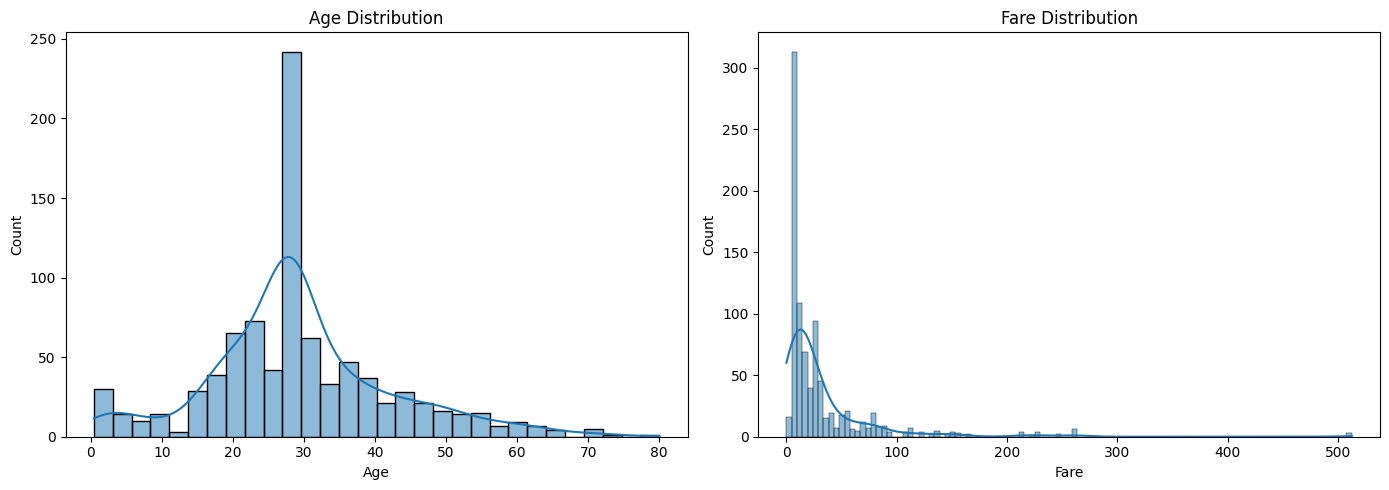

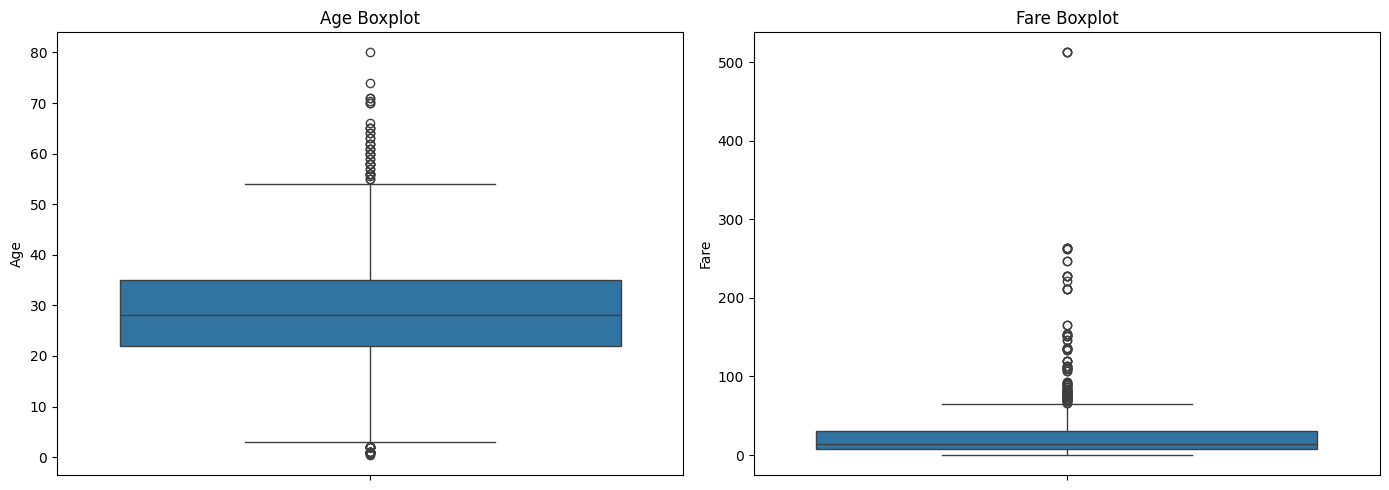

Age IQR analysis:
{'Q1': np.float64(22.0), 'Q3': np.float64(35.0), 'IQR': np.float64(13.0), 'lower_bound': np.float64(2.5), 'upper_bound': np.float64(54.5), 'outlier_count': 65}

Fare IQR analysis:
{'Q1': np.float64(7.8958), 'Q3': np.float64(31.0), 'IQR': np.float64(23.1042), 'lower_bound': np.float64(-26.7605), 'upper_bound': np.float64(65.6563), 'outlier_count': 114}

Fare statistics:
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05
Skewness: 4.801440211044194

Skewness conclusion:
Fare is right-skewed because mean > median > mode.


In [6]:
# Task 3: Univariate analysis - Age and Fare

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Histograms
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["age"], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.histplot(df["fare"], kde=True, ax=axes[1])
axes[1].set_title("Fare Distribution")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


# -----------------------------
# Boxplots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df["age"], ax=axes[0])
axes[0].set_title("Age Boxplot")
axes[0].set_ylabel("Age")

sns.boxplot(y=df["fare"], ax=axes[1])
axes[1].set_title("Fare Boxplot")
axes[1].set_ylabel("Fare")

plt.tight_layout()
plt.show()


# -----------------------------
# IQR outlier counts
# -----------------------------
def iqr_outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    }


age_outliers = iqr_outlier_count(df["age"])
fare_outliers = iqr_outlier_count(df["fare"])

print("Age IQR analysis:")
print(age_outliers)

print("\nFare IQR analysis:")
print(fare_outliers)


# -----------------------------
# Fare statistics
# -----------------------------
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode().iloc[0]
fare_skewness = df["fare"].skew()

print("\nFare statistics:")
print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)
print("Skewness:", fare_skewness)

# Determine skewness using mean/median/mode ordering
if fare_mean > fare_median > fare_mode:
    skew_conclusion = "Fare is right-skewed because mean > median > mode."
elif fare_mean < fare_median < fare_mode:
    skew_conclusion = "Fare is left-skewed because mean < median < mode."
else:
    skew_conclusion = "Fare does not follow a simple mean > median > mode or mean < median < mode ordering."

print("\nSkewness conclusion:")
print(skew_conclusion)

Survival rate by sex (%):


,survived
sex,
female,74.04
male,18.89


Survival rate by passenger class (%):


,survived
pclass,
1,62.62
2,47.28
3,24.24


Survival rate by sex AND passenger class (%):


,sex,pclass,passengers,survival_rate_percent
0,male,1,122,36.89
1,male,2,108,15.74
2,male,3,347,13.54
3,female,1,92,96.74
4,female,2,76,92.11
5,female,3,144,50.00


Correlation matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


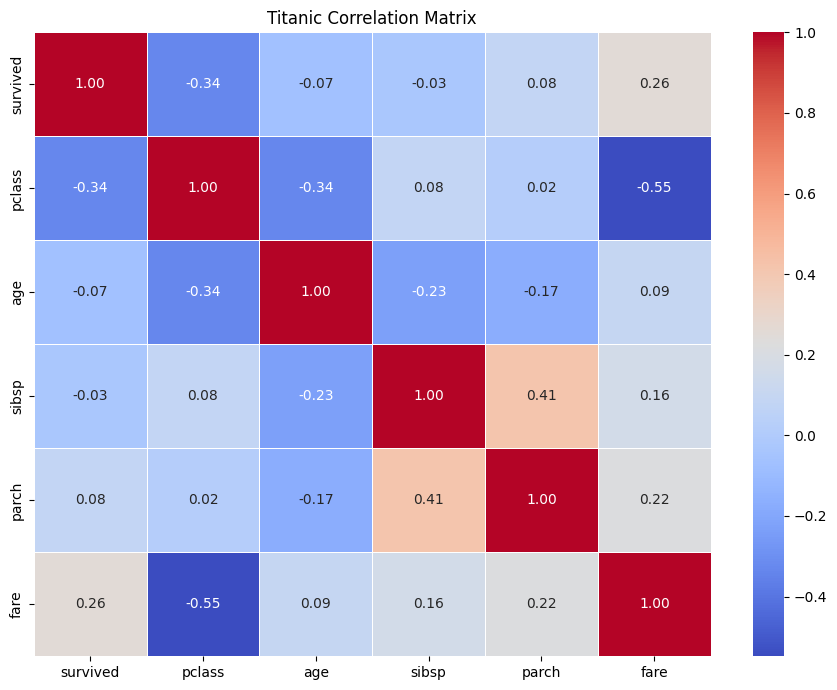

Two strongest absolute off-diagonal correlations:


,feature_1,feature_2,correlation,absolute_correlation
0,pclass,fare,-0.548193,0.548193
1,sibsp,parch,0.414542,0.414542


In [7]:
# Task 4: Bivariate analysis
# Survival rates + required 6-column correlation matrix

# --------------------------------------------------
# 1. Survival rate by sex
# --------------------------------------------------
survival_by_sex = (
    df.groupby("sex", observed=True)["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by sex (%):")
display(survival_by_sex)


# --------------------------------------------------
# 2. Survival rate by passenger class
# --------------------------------------------------
survival_by_pclass = (
    df.groupby("pclass", observed=True)["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by passenger class (%):")
display(survival_by_pclass)


# --------------------------------------------------
# 3. Survival rate by sex AND passenger class
#    Using boolean masking / combinations
# --------------------------------------------------
groups = []

for sex_value in df["sex"].unique():
    for pclass_value in sorted(df["pclass"].unique()):
        mask = (df["sex"] == sex_value) & (df["pclass"] == pclass_value)

        group_count = mask.sum()

        if group_count > 0:
            survival_rate = df.loc[mask, "survived"].mean() * 100

            groups.append({
                "sex": sex_value,
                "pclass": pclass_value,
                "passengers": group_count,
                "survival_rate_percent": round(survival_rate, 2)
            })

survival_by_sex_pclass = pd.DataFrame(groups)

print("Survival rate by sex AND passenger class (%):")
display(survival_by_sex_pclass)


# --------------------------------------------------
# 4. Correlation matrix
# EXACTLY the six required columns
# --------------------------------------------------
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[corr_columns].corr()

print("Correlation matrix:")
display(corr_matrix)


# --------------------------------------------------
# 5. Heatmap
# --------------------------------------------------
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Titanic Correlation Matrix")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 6. Find the two strongest absolute off-diagonal
#    correlations
# --------------------------------------------------
corr_pairs = []

for i in range(len(corr_columns)):
    for j in range(i + 1, len(corr_columns)):
        col1 = corr_columns[i]
        col2 = corr_columns[j]
        correlation = corr_matrix.loc[col1, col2]

        corr_pairs.append({
            "feature_1": col1,
            "feature_2": col2,
            "correlation": correlation,
            "absolute_correlation": abs(correlation)
        })

corr_pairs_df = pd.DataFrame(corr_pairs)

top_two = (
    corr_pairs_df
    .sort_values("absolute_correlation", ascending=False)
    .head(2)
    .reset_index(drop=True)
)

print("Two strongest absolute off-diagonal correlations:")
display(top_two)

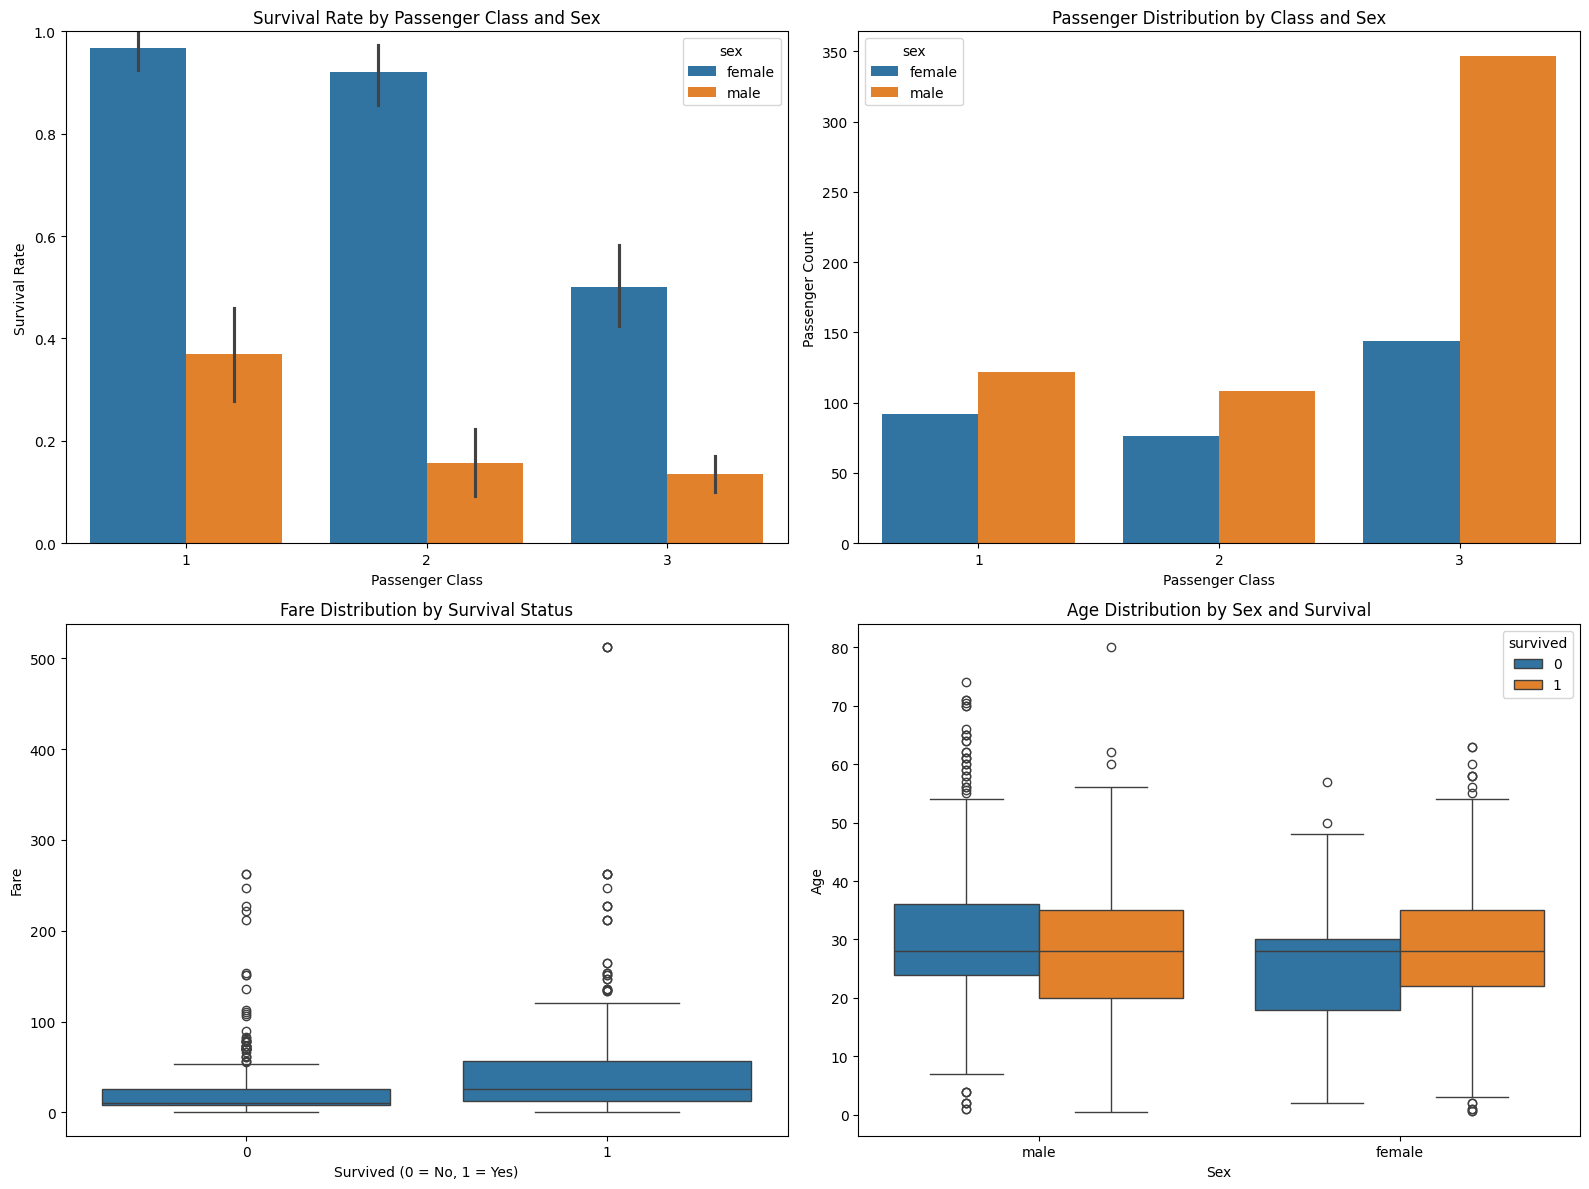

In [9]:
# Task 5: Multivariate data story
# Four distinct charts

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --------------------------------------------------
# Chart 1: Survival rate by sex and passenger class
# --------------------------------------------------
sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Survival Rate by Passenger Class and Sex")
axes[0, 0].set_xlabel("Passenger Class")
axes[0, 0].set_ylabel("Survival Rate")
axes[0, 0].set_ylim(0, 1)


# --------------------------------------------------
# Chart 2: Passenger counts by class and sex
# --------------------------------------------------
sns.countplot(
    data=df,
    x="pclass",
    hue="sex",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Passenger Distribution by Class and Sex")
axes[0, 1].set_xlabel("Passenger Class")
axes[0, 1].set_ylabel("Passenger Count")


# --------------------------------------------------
# Chart 3: Fare distribution by survival status
# --------------------------------------------------
sns.boxplot(
    data=df,
    x="survived",
    y="fare",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Fare Distribution by Survival Status")
axes[1, 0].set_xlabel("Survived (0 = No, 1 = Yes)")
axes[1, 0].set_ylabel("Fare")


# --------------------------------------------------
# Chart 4: Age distribution by survival and sex
# --------------------------------------------------
sns.boxplot(
    data=df,
    x="sex",
    y="age",
    hue="survived",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Age Distribution by Sex and Survival")
axes[1, 1].set_xlabel("Sex")
axes[1, 1].set_ylabel("Age")


plt.tight_layout()
plt.show()

In [10]:
# Task 5: Written interpretations for the four charts

print("""
Chart 1 — Survival Rate by Passenger Class and Sex:
Survival rates differ substantially by both sex and passenger class.
Female passengers had higher survival rates than male passengers within every passenger class,
while survival generally decreased from first class to third class.

Chart 2 — Passenger Distribution by Class and Sex:
The passenger composition differs across the three passenger classes.
Third class contains the largest number of passengers, providing context for the survival-rate
comparisons across sex and passenger class.

Chart 3 — Fare Distribution by Survival Status:
The fare distribution differs between passengers who survived and those who did not.
Survivors generally had higher fare values, although both groups contain substantial fare outliers.

Chart 4 — Age Distribution by Sex and Survival:
Age distributions vary across sex and survival groups.
The differences suggest that survival patterns involve both age and sex rather than age alone.
""")


Chart 1 — Survival Rate by Passenger Class and Sex:
Survival rates differ substantially by both sex and passenger class.
Female passengers had higher survival rates than male passengers within every passenger class,
while survival generally decreased from first class to third class.

Chart 2 — Passenger Distribution by Class and Sex:
The passenger composition differs across the three passenger classes.
Third class contains the largest number of passengers, providing context for the survival-rate
comparisons across sex and passenger class.

Chart 3 — Fare Distribution by Survival Status:
The fare distribution differs between passengers who survived and those who did not.
Survivors generally had higher fare values, although both groups contain substantial fare outliers.

Chart 4 — Age Distribution by Sex and Survival:
Age distributions vary across sex and survival groups.
The differences suggest that survival patterns involve both age and sex rather than age alone.



In [11]:
# Task 6: Exploratory z-score standardization of age and fare

from sklearn.preprocessing import StandardScaler

# Before standardization
before_stats = df[["age", "fare"]].agg(["mean", "std"]).T
before_stats.columns = ["mean_before", "std_before"]

# Standardize age and fare
scaler_exploratory = StandardScaler()

df[["age", "fare"]] = scaler_exploratory.fit_transform(
    df[["age", "fare"]]
)

# After standardization
after_stats = df[["age", "fare"]].agg(["mean", "std"]).T
after_stats.columns = ["mean_after", "std_after"]

# Compare
standardization_comparison = before_stats.join(after_stats)

print("Before vs after standardization:")
display(standardization_comparison)

print("\nMeans after standardization should be approximately 0.")
print("Standard deviations should be approximately 1.")

Before vs after standardization:


,mean_before,std_before,mean_after,std_after
age,29.315152,12.984932,2.717486e-16,1.000563
fare,32.096681,49.697504,1.398706e-16,1.000563



Means after standardization should be approximately 0.
Standard deviations should be approximately 1.


In [12]:
# Restore the cleaned dataset on its original scale
# No second sns.load_dataset() call is used.

df_model = pd.read_csv("analytics/titanic.csv")

# Apply the same Task 2 cleaning decisions
age_median_raw = df_model["age"].median()

df_model["age"] = df_model["age"].fillna(age_median_raw)

df_model = df_model.dropna(
    subset=["embarked", "embark_town"]
).copy()

df_model = df_model.drop(
    columns=["deck"],
    errors="ignore"
)

print("Cleaned modeling dataset:")
print("Shape:", df_model.shape)

print("\nRemaining missing values:")
display(df_model.isnull().sum()[df_model.isnull().sum() > 0])

print("\nAge mean:", df_model["age"].mean())
print("Fare mean:", df_model["fare"].mean())

Cleaned modeling dataset:
Shape: (889, 14)

Remaining missing values:


,0



Age mean: 29.315151856017994
Fare mean: 32.09668087739032


In [13]:
# Task 7: Stratified train/test split

from sklearn.model_selection import train_test_split

# Classification target
X = df_model.drop(columns=["survived"])
y = df_model["survived"]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nOverall class distribution:")
print(y.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nAbsolute class counts:")
print("Overall:")
print(y.value_counts().sort_index())

print("\nTraining:")
print(y_train.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())

print("""
Justification:
Stratification preserves approximately the same survived/not-survived class
proportions in both the training and test sets. This is important because the
Titanic target is imbalanced, with fewer survivors than non-survivors.
""")

Training set shape: (711, 13)
Test set shape: (178, 13)

Overall class distribution:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64

Training class distribution:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64

Test class distribution:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64

Absolute class counts:
Overall:
survived
0    549
1    340
Name: count, dtype: int64

Training:
survived
0    439
1    272
Name: count, dtype: int64

Test:
survived
0    110
1     68
Name: count, dtype: int64

Justification:
Stratification preserves approximately the same survived/not-survived class
proportions in both the training and test sets. This is important because the
Titanic target is imbalanced, with fewer survivors than non-survivors.



In [14]:
# Task 8: Preprocessing pipeline
# All preprocessing is fitted only on the training data.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Columns to use
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing:
# median imputation + standardization
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# most-frequent imputation + one-hot encoding
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Fit ONLY on X_train
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted training preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Preprocessor fitted on X_train only.")

print("\nOriginal training shape:", X_train.shape)
print("Original test shape:", X_test.shape)

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

print("\nOne-hot encoded categories:")
onehot_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
print(onehot_encoder.get_feature_names_out(categorical_features))

Preprocessor fitted on X_train only.

Original training shape: (711, 13)
Original test shape: (178, 13)

Processed training shape: (711, 10)
Processed test shape: (178, 10)

Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']

One-hot encoded categories:
['sex_female' 'sex_male' 'embarked_C' 'embarked_Q' 'embarked_S']


In [15]:
# Task 9: Train three classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Define the three classifiers
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

# Store complete pipelines
model_pipelines = {}

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    model_pipelines[model_name] = pipeline

    print(f"{model_name}: trained successfully")

print("\nAll three models trained on the same stratified train/test split.")

Logistic Regression: trained successfully
Decision Tree: trained successfully
Random Forest: trained successfully

All three models trained on the same stratified train/test split.


In [16]:
# Task 10: Evaluate all three classification models

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

results = []

for model_name, pipeline in model_pipelines.items():

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc
    })

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")


# Side-by-side comparison table
classification_results = pd.DataFrame(results)

print("\nClassification Model Comparison:")
display(
    classification_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC AUC": "{:.4f}"
    })
)


Logistic Regression
-------------------
Confusion Matrix:
[[97 13]
 [21 47]]
Accuracy : 0.8090
Precision: 0.7833
Recall   : 0.6912
F1 Score : 0.7344
ROC AUC  : 0.8610

Decision Tree
-------------
Confusion Matrix:
[[98 12]
 [30 38]]
Accuracy : 0.7640
Precision: 0.7600
Recall   : 0.5588
F1 Score : 0.6441
ROC AUC  : 0.8374

Random Forest
-------------
Confusion Matrix:
[[95 15]
 [19 49]]
Accuracy : 0.8090
Precision: 0.7656
Recall   : 0.7206
F1 Score : 0.7424
ROC AUC  : 0.8196

Classification Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196


In [18]:
# Task 11: Class imbalance setup

!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [19]:
# Task 11: Compare baseline, class_weight='balanced', and SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

imbalance_results = []

# --------------------------------------------------
# 1. Baseline Logistic Regression
# --------------------------------------------------

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

imbalance_results.append({
    "Method": "Baseline",
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1 Score": f1_score(y_test, baseline_pred)
})


# --------------------------------------------------
# 2. Logistic Regression with class_weight='balanced'
# --------------------------------------------------

balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)

imbalance_results.append({
    "Method": "Class Weight Balanced",
    "Precision": precision_score(y_test, balanced_pred),
    "Recall": recall_score(y_test, balanced_pred),
    "F1 Score": f1_score(y_test, balanced_pred)
})


# --------------------------------------------------
# 3. Logistic Regression with SMOTE
# --------------------------------------------------
# SMOTE is applied ONLY to the training data
# inside the pipeline.

smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

smote_pipeline.fit(X_train, y_train)

smote_pred = smote_pipeline.predict(X_test)

imbalance_results.append({
    "Method": "SMOTE",
    "Precision": precision_score(y_test, smote_pred),
    "Recall": recall_score(y_test, smote_pred),
    "F1 Score": f1_score(y_test, smote_pred)
})


# --------------------------------------------------
# Comparison table
# --------------------------------------------------

imbalance_results_df = pd.DataFrame(imbalance_results)

print("Class Imbalance Comparison:")
display(
    imbalance_results_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

Class Imbalance Comparison:


,Method,Precision,Recall,F1 Score
0,Baseline,0.7833,0.6912,0.7344
1,Class Weight Balanced,0.7183,0.7500,0.7338
2,SMOTE,0.7353,0.7353,0.7353


In [20]:
# Task 12: GridSearchCV for Random Forest

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Random Forest with OOB enabled
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            oob_score=True,
            bootstrap=True
        ))
    ]
)

# Required hyperparameter grid
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

# Grid search
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print("GridSearchCV completed.")

print("\nBest parameters:")
print(rf_grid.best_params_)

print("\nBest cross-validation F1 score:")
print(f"{rf_grid.best_score_:.4f}")

# Best fitted pipeline
best_rf_pipeline = rf_grid.best_estimator_

# Extract fitted Random Forest
best_rf_model = best_rf_pipeline.named_steps["classifier"]

print("\nOOB score:")
print(f"{best_rf_model.oob_score_:.4f}")

GridSearchCV completed.

Best parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best cross-validation F1 score:
0.7408

OOB score:
0.8214


In [22]:
# Evaluate tuned Random Forest on the held-out test set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

best_rf_pred = best_rf_pipeline.predict(X_test)
best_rf_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("Tuned Random Forest — Test Set")
print("--------------------------------")
print("Confusion Matrix:")
print(confusion_matrix(y_test, best_rf_pred))

print(f"Accuracy : {accuracy_score(y_test, best_rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_rf_pred):.4f}")
print(f"Recall   : {recall_score(y_test, best_rf_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, best_rf_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, best_rf_prob):.4f}")

Tuned Random Forest — Test Set
--------------------------------
Confusion Matrix:
[[103   7]
 [ 23  45]]
Accuracy : 0.8315
Precision: 0.8654
Recall   : 0.6618
F1 Score : 0.7500
ROC AUC  : 0.8389


In [23]:
# Task 13: Multivariate Linear Regression to predict Fare

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Features used to predict fare
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df_model[regression_features]
y_reg = df_model["fare"]

# Train/test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Preprocessing for regression
reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

reg_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reg_numeric_transformer, reg_numeric_features),
        ("cat", reg_categorical_transformer, reg_categorical_features)
    ],
    remainder="drop"
)

# Complete regression pipeline
regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Fit on training data only
regression_pipeline.fit(X_reg_train, y_reg_train)

# Predictions
y_reg_pred = regression_pipeline.predict(X_reg_test)

# Metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

# Number of observations and predictors after preprocessing
n = len(y_reg_test)

reg_feature_names = regression_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

p = len(reg_feature_names)

# Adjusted R-squared
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Multivariate Linear Regression Results")
print("--------------------------------------")
print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"R²         : {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"\nTest observations (n): {n}")
print(f"Predictors after encoding (p): {p}")

Multivariate Linear Regression Results
--------------------------------------
MAE        : 21.1386
RMSE       : 41.7465
R²         : 0.3468
Adjusted R²: 0.3118

Test observations (n): 178
Predictors after encoding (p): 9


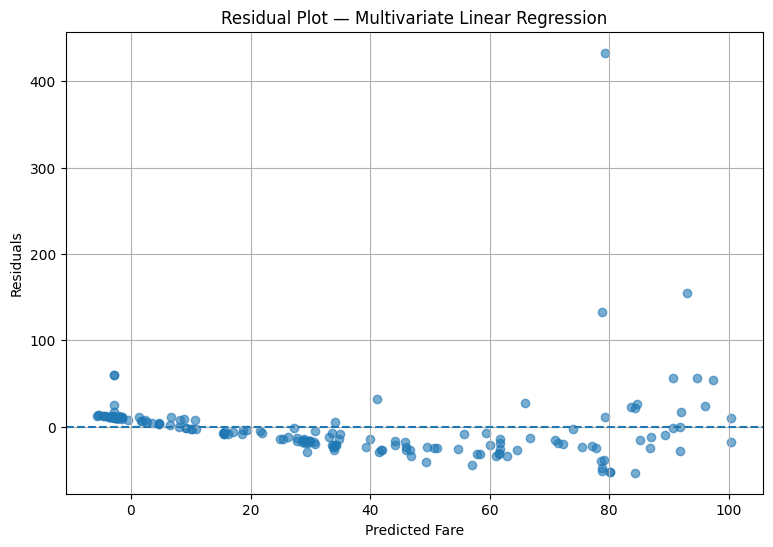

In [24]:
# Residual plot

residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(9, 6))

plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Multivariate Linear Regression")

plt.grid(True)
plt.show()

In [25]:
# Task 14: Final comparison of classification and regression models

# --------------------------------------------------
# Classification comparison
# --------------------------------------------------

final_classification_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8090,
        "Precision": 0.7833,
        "Recall": 0.6912,
        "F1 Score": 0.7344,
        "ROC AUC": 0.8610
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.7640,
        "Precision": 0.7600,
        "Recall": 0.5588,
        "F1 Score": 0.6441,
        "ROC AUC": 0.8374
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.8090,
        "Precision": 0.7656,
        "Recall": 0.7206,
        "F1 Score": 0.7424,
        "ROC AUC": 0.8196
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": 0.8315,
        "Precision": 0.8654,
        "Recall": 0.6618,
        "F1 Score": 0.7500,
        "ROC AUC": 0.8389
    }
])

print("FINAL CLASSIFICATION COMPARISON")
display(
    final_classification_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC AUC": "{:.4f}"
    })
)


# --------------------------------------------------
# Regression comparison
# --------------------------------------------------

final_regression_results = pd.DataFrame([
    {
        "Model": "Multivariate Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Adjusted R²": adjusted_r2
    }
])

print("\nFINAL REGRESSION COMPARISON")
display(
    final_regression_results.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R²": "{:.4f}",
        "Adjusted R²": "{:.4f}"
    })
)


# --------------------------------------------------
# Final recommendation
# --------------------------------------------------

print("""
FINAL RECOMMENDATION

For Titanic survival classification, the tuned Random Forest is selected
as the final pipeline because it achieved 0.8315 accuracy and the highest
F1 score of 0.7500 among the evaluated classification models. It also
achieved the highest precision at 0.8654, although its recall of 0.6618
is lower than the original Random Forest recall of 0.7206. Logistic
Regression achieved the highest ROC AUC of 0.8610, indicating strong
overall ranking performance, while the tuned Random Forest provides a
stronger accuracy/precision/F1 combination for the final pipeline.

For fare prediction, the multivariate linear regression achieved MAE
21.1386, RMSE 41.7465, R² 0.3468, and adjusted R² 0.3118. The residual
plot showed evidence of heteroscedasticity, particularly at higher
predicted fare values, so fare predictions should be interpreted with
this limitation in mind.
""")

FINAL CLASSIFICATION COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196
3,Tuned Random Forest,0.8315,0.8654,0.6618,0.7500,0.8389



FINAL REGRESSION COMPARISON


,Model,MAE,RMSE,R²,Adjusted R²
0,Multivariate Linear Regression,21.1386,41.7465,0.3468,0.3118



FINAL RECOMMENDATION

For Titanic survival classification, the tuned Random Forest is selected
as the final pipeline because it achieved 0.8315 accuracy and the highest
F1 score of 0.7500 among the evaluated classification models. It also
achieved the highest precision at 0.8654, although its recall of 0.6618
is lower than the original Random Forest recall of 0.7206. Logistic
Regression achieved the highest ROC AUC of 0.8610, indicating strong
overall ranking performance, while the tuned Random Forest provides a
stronger accuracy/precision/F1 combination for the final pipeline.

For fare prediction, the multivariate linear regression achieved MAE
21.1386, RMSE 41.7465, R² 0.3468, and adjusted R² 0.3118. The residual
plot showed evidence of heteroscedasticity, particularly at higher
predicted fare values, so fare predictions should be interpreted with
this limitation in mind.



In [26]:
# Task 15: Save and reload the complete fitted pipeline

import os
import joblib
import pandas as pd

# Make sure analytics directory exists
os.makedirs("analytics", exist_ok=True)

# The tuned Random Forest pipeline already contains:
# preprocessing + estimator
full_pipeline = best_rf_pipeline

# Save the complete fitted pipeline
pipeline_path = "analytics/best_titanic_pipeline.joblib"

joblib.dump(full_pipeline, pipeline_path)

print("Pipeline saved successfully:")
print(pipeline_path)

# --------------------------------------------------
# Reload the saved pipeline
# --------------------------------------------------

loaded_pipeline = joblib.load(pipeline_path)

print("\nPipeline reloaded successfully.")
print("Pipeline steps:")
print(loaded_pipeline.named_steps)

Pipeline saved successfully:
analytics/best_titanic_pipeline.joblib

Pipeline reloaded successfully.
Pipeline steps:
{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked'])]), 'classifier': RandomForestClassifier(max_depth=5, n_estimators=200, oob_score=True,
                       random_sta

In [27]:
# Test prediction using the reloaded pipeline and raw input

# Take one raw passenger record from the test set
raw_input = X_test.iloc[[0]].copy()

# Prediction from the reloaded complete pipeline
loaded_prediction = loaded_pipeline.predict(raw_input)
loaded_probability = loaded_pipeline.predict_proba(raw_input)[:, 1]

print("Raw input:")
display(raw_input)

print("Actual survival:", y_test.iloc[0])
print("Predicted survival:", loaded_prediction[0])
print(f"Predicted survival probability: {loaded_probability[0]:.4f}")

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
160,3,male,44.0,0,1,16.1,S,Third,man,True,Southampton,no,False


Actual survival: 0
Predicted survival: 0
Predicted survival probability: 0.1684


In [28]:
# Create the analytics README

analytics_readme = """
# Module 2 — Titanic Analytics and Machine Learning

## Overview

This module performs exploratory data analysis, preprocessing, classification,
hyperparameter tuning, class-imbalance analysis, and multivariate linear
regression using the classic Titanic dataset.

The dataset was loaded once using `seaborn.load_dataset("titanic")` and saved
as `titanic.csv` for offline reproducibility. The same cleaned dataset was
used throughout the analysis and modeling workflow.

## Dataset

Original dataset:
- Rows: 891
- Columns: 15

Missing values in the original dataset:
- age: 177 missing (19.87%)
- embarked: 2 missing (0.22%)
- deck: 688 missing (77.22%)
- embark_town: 2 missing (0.22%)

Cleaning strategy:
- `age` (19.87% missing): median imputation using median = 28.0
- `embarked` (0.22% missing): dropped rows
- `embark_town` (0.22% missing): dropped rows
- `deck` (77.22% missing): dropped because of very high missingness

Final cleaned dataset:
- Rows: 889
- Columns: 14
- Remaining missing values: none

## Exploratory Data Analysis

### Age and Fare

IQR analysis:
- Age Q1: 22.0
- Age Q3: 35.0
- Age IQR: 13.0
- Age outliers: 65
- Fare Q1: 7.8958
- Fare Q3: 31.0
- Fare IQR: 23.1042
- Fare outliers: 114

Fare statistics:
- Mean: 32.0967
- Median: 14.4542
- Mode: 8.05
- Skewness: 4.8014

Since mean > median > mode and skewness is strongly positive, fare is
right-skewed.

### Survival Analysis

Survival rate by sex:
- Female: 74.04%
- Male: 18.89%

Survival rate by passenger class:
- First class: 62.62%
- Second class: 47.28%
- Third class: 24.24%

Survival by sex and class showed substantial differences across groups,
with female passengers having higher survival rates within each class.

### Correlation Analysis

The required six-column correlation matrix used:
- survived
- pclass
- age
- sibsp
- parch
- fare

Strongest absolute off-diagonal correlations:
- pclass vs fare: -0.5482
- sibsp vs parch: 0.4145

### Multivariate Charts

Four multivariate charts were created:
1. Survival rate by passenger class and sex
2. Passenger distribution by class and sex
3. Fare distribution by survival status
4. Age distribution by sex and survival status

The charts showed clear differences in survival patterns across sex and
passenger class, differences in passenger composition across classes, higher
fare distributions among survivors, and age-distribution differences across
sex and survival groups.

## Standardization

Exploratory z-score standardization was applied to age and fare.

Before standardization:
- Age mean: 29.3152
- Age standard deviation: 12.9849
- Fare mean: 32.0967
- Fare standard deviation: 49.6975

After standardization, both variables had means approximately equal to zero
and standard deviations approximately equal to one.

## Classification

A stratified 80/20 train-test split was used.

Class distribution:
- Overall: 61.75% non-survived, 38.25% survived
- Training: 61.74% non-survived, 38.26% survived
- Test: 61.80% non-survived, 38.20% survived

Features used for classification:
- pclass
- sex
- age
- sibsp
- parch
- fare
- embarked

Preprocessing:
- Numeric features: median imputation + StandardScaler
- Categorical features: most-frequent imputation + one-hot encoding
- Preprocessing was fitted only on the training data.

### Classification Results

| Model | Accuracy | Precision | Recall | F1 | ROC AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8090 | 0.7833 | 0.6912 | 0.7344 | 0.8610 |
| Decision Tree | 0.7640 | 0.7600 | 0.5588 | 0.6441 | 0.8374 |
| Random Forest | 0.8090 | 0.7656 | 0.7206 | 0.7424 | 0.8196 |
| Tuned Random Forest | 0.8315 | 0.8654 | 0.6618 | 0.7500 | 0.8389 |

The tuned Random Forest achieved 0.8315 accuracy, 0.8654 precision, and
0.7500 F1. Logistic Regression achieved the highest ROC AUC at 0.8610.
The tuned Random Forest was selected as the final saved classification
pipeline based on its accuracy, precision, and F1 results, while its lower
recall compared with the original Random Forest was noted.

## Class Imbalance

The following Logistic Regression approaches were compared:

| Method | Precision | Recall | F1 |
|---|---:|---:|---:|
| Baseline | 0.7833 | 0.6912 | 0.7344 |
| Class Weight Balanced | 0.7183 | 0.7500 | 0.7338 |
| SMOTE | 0.7353 | 0.7353 | 0.7353 |

Class weighting increased recall while reducing precision. SMOTE produced
balanced precision and recall of 0.7353. The F1 scores remained very close
across all three approaches.

SMOTE was applied only to the training data.

## Random Forest Grid Search

GridSearchCV searched:
- n_estimators: 100, 200
- max_depth: None, 5, 10
- max_features: sqrt, log2

Best parameters:
- n_estimators: 200
- max_depth: 5
- max_features: sqrt

Best cross-validation F1: 0.7408
OOB score: 0.8214

## Fare Regression

A multivariate Linear Regression model was used to predict fare from:
- pclass
- sex
- age
- sibsp
- parch
- embarked

Results:
- MAE: 21.1386
- RMSE: 41.7465
- R²: 0.3468
- Adjusted R²: 0.3118

The residual plot showed evidence of non-constant variance. Residuals had
a wider spread at higher predicted fare values, with several large positive
residuals, suggesting heteroscedasticity.

## Final Model

The complete fitted tuned Random Forest pipeline was saved as:

`best_titanic_pipeline.joblib`

The saved pipeline contains both:
1. preprocessing
2. Random Forest classifier

The pipeline was reloaded successfully and tested using raw passenger input.

Example:
- Actual survival: 0
- Predicted survival: 0
- Predicted survival probability: 0.1684

## Files

- `01_eda.ipynb` — complete EDA and modeling workflow
- `titanic.csv` — saved Titanic dataset for offline reproducibility
- `best_titanic_pipeline.joblib` — complete fitted classification pipeline
- `README.md` — Module 2 documentation

## Completion Status

Module 2 — Analytics: Complete.
"""

with open("analytics/README.md", "w", encoding="utf-8") as f:
    f.write(analytics_readme)

print("Created analytics/README.md")

Created analytics/README.md


In [29]:
import os

for path in [
    "analytics/titanic.csv",
    "analytics/best_titanic_pipeline.joblib",
    "analytics/README.md"
]:
    print(path, "->", os.path.getsize(path), "bytes")

analytics/titanic.csv -> 57018 bytes
analytics/best_titanic_pipeline.joblib -> 844488 bytes
analytics/README.md -> 5856 bytes
